In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


In [3]:
dataset = pd.read_csv(r'D:\data analysis\Projects\Food Delivery Pattern Analysis\output\transactions\transactions.csv')
dataset.head()

,order_id,customer_id,restaurant,items,item_names,item_categories,total_price,order_date,order_hour,order_day,n_items,payment_method,delivery_time_min,order_rating
0,ORD00001,CUST0392,El Classico,"M0077,M0250","Veggie Supreme Pizza,Umm Ali","Pizza,Desserts",126.0,2026-04-02,14,Thursday,2,Cash,51,2.6
1,ORD00002,CUST0465,Crave It,"M0296,M0342,M0273,M0343,M0362","Avocado Smoothie,French Onion Soup,Mango Smoot...","Beverages,Soups,Beverages,Soups,Soups",194.0,2026-04-09,20,Thursday,5,Credit Card,26,3.0
2,ORD00003,CUST0428,Urban Bites,"M0324,M0243","Tuna Melt,Tiramisu","Sandwiches,Desserts",87.0,2025-12-12,16,Friday,2,Credit Card,56,4.8
3,ORD00004,CUST0480,Fresh & Fit,"M0120,M0042","Salmon Nigiri (2Pcs),Margherita Pizza","Sushi,Pizza",142.0,2026-04-21,8,Tuesday,2,Wallet,28,4.1
4,ORD00005,CUST0037,Golden Fork,"M0346,M0278","French Onion Soup,Iced Latte","Soups,Beverages",64.0,2025-11-13,12,Thursday,2,Cash,35,4.4


In [4]:
dataset["item_names"] = dataset["item_names"].apply(lambda x: x.split(","))

In [5]:
dataset.head()

,order_id,customer_id,restaurant,items,item_names,item_categories,total_price,order_date,order_hour,order_day,n_items,payment_method,delivery_time_min,order_rating
0,ORD00001,CUST0392,El Classico,"M0077,M0250","[Veggie Supreme Pizza, Umm Ali]","Pizza,Desserts",126.0,2026-04-02,14,Thursday,2,Cash,51,2.6
1,ORD00002,CUST0465,Crave It,"M0296,M0342,M0273,M0343,M0362","[Avocado Smoothie, French Onion Soup, Mango Sm...","Beverages,Soups,Beverages,Soups,Soups",194.0,2026-04-09,20,Thursday,5,Credit Card,26,3.0
2,ORD00003,CUST0428,Urban Bites,"M0324,M0243","[Tuna Melt, Tiramisu]","Sandwiches,Desserts",87.0,2025-12-12,16,Friday,2,Credit Card,56,4.8
3,ORD00004,CUST0480,Fresh & Fit,"M0120,M0042","[Salmon Nigiri (2Pcs), Margherita Pizza]","Sushi,Pizza",142.0,2026-04-21,8,Tuesday,2,Wallet,28,4.1
4,ORD00005,CUST0037,Golden Fork,"M0346,M0278","[French Onion Soup, Iced Latte]","Soups,Beverages",64.0,2025-11-13,12,Thursday,2,Cash,35,4.4


In [8]:
def clean_items(x):
    x = str(x).replace('[', '').replace(']', '')
    items = [i.strip().replace("'", "").replace('"', '') for i in x.split(',')]
    items = [i for i in items if i != '']
    return list(set(items))

dataset['item_names'] = dataset['item_names'].apply(clean_items)

In [38]:
transactions = dataset['item_names'].tolist()

transactions[:]

[['Veggie Supreme Pizza', 'Umm Ali'],
 ['Mushroom Cream Soup',
  'Avocado Smoothie',
  'French Onion Soup',
  'Mango Smoothie'],
 ['Tuna Melt', 'Tiramisu'],
 ['Margherita Pizza', 'Salmon Nigiri (2Pcs)'],
 ['Iced Latte', 'French Onion Soup'],
 ['Spicy Tuna Roll (8Pcs)', 'Avocado Smoothie', 'Tiramisu'],
 ['Quinoa Power Bowl',
  'Chicken Shawarma Wrap',
  'Blt Sandwich',
  'Margherita Pizza'],
 ['Veggie Roll (8Pcs)', 'French Onion Soup'],
 ['Bbq Bacon Burger', 'Caesar Salad'],
 ['French Onion Soup', 'Strawberry Milkshake'],
 ['Spicy Jalapeño Burger'],
 ['Mango Smoothie', 'Veggie Roll (8Pcs)', 'Salmon Nigiri (2Pcs)'],
 ['Egg & Avocado Toast', 'Cheesecake Slice', 'Pasta Carbonara'],
 ['Cheese Shawarma', 'Mixed Grill Wrap', 'Umm Ali', 'Cheesecake Slice'],
 ['Mint Lemonade', 'Falafel Wrap'],
 ['Strawberry Milkshake', 'Pesto Pasta', 'Veggie Garden Burger'],
 ['Iced Latte', 'Veggie Roll (8Pcs)'],
 ['California Roll (8Pcs)', 'Tiramisu'],
 ['Fresh Orange Juice',
  'Falafel Wrap',
  'Tuna Melt',
 

In [39]:
items = set()
for t in transactions:
    for i in t:
        items.add(i)

print(len(items))

70


In [ ]:
n_transactions = len(transactions)
avg_basket_size = sum(len(t) for t in transactions) / n_transactions

minimum_occurrence = int(n_transactions * 0.01)
min_support = minimum_occurrence / n_transactions

if avg_basket_size <= 2.5:
    min_confidence = 0.20
elif avg_basket_size <= 4:
    min_confidence = 0.25
else:
    min_confidence = 0.30

min_lift = 1

print("Min Support:", min_support)
print("Min Confidence:", min_confidence)
print("Min Lift:", min_lift)

Min Support: 0.01
Min Confidence: 0.25
Min Lift: 1.2


In [44]:
from apyori import apriori

rules = apriori(
    transactions,
    min_support=0.001,
    min_confidence=min_confidence,
    min_lift=1,
    min_length=2
)


In [45]:
rules_list = list(rules)
rules_list

[RelationRecord(items=frozenset({'Bbq Chicken Pizza', 'Avocado Smoothie', 'Caprese Salad'}), support=0.001, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Bbq Chicken Pizza', 'Avocado Smoothie'}), items_add=frozenset({'Caprese Salad'}), confidence=0.6666666666666666, lift=19.323671497584538), OrderedStatistic(items_base=frozenset({'Avocado Smoothie', 'Caprese Salad'}), items_add=frozenset({'Bbq Chicken Pizza'}), confidence=1.0, lift=17.699115044247787), OrderedStatistic(items_base=frozenset({'Bbq Chicken Pizza', 'Caprese Salad'}), items_add=frozenset({'Avocado Smoothie'}), confidence=1.0, lift=19.607843137254903)]),
 RelationRecord(items=frozenset({'Avocado Smoothie', 'Truffle Mushroom Pizza', 'Caesar Salad'}), support=0.001, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Avocado Smoothie', 'Caesar Salad'}), items_add=frozenset({'Truffle Mushroom Pizza'}), confidence=0.4, lift=15.094339622641511), OrderedStatistic(items_base=frozenset({'Avocado Smoothie', 'Tru

In [47]:
def inspect(rules):
    lhs = [tuple(rule[0])[0] for rule in rules]
    rhs = [tuple(rule[0])[1] for rule in rules]
    supports = [rule[1] for rule in rules]
    confidences = [rule[2][0][2] for rule in rules]
    lifts = [rule[2][0][3] for rule in rules]
    return list(zip(lhs, rhs, supports, confidences, lifts))
resultsinDataFrame = pd.DataFrame(inspect(rules_list), columns=['Left Hand Side', 'Right Hand Side', 'Support', 'Confidence', 'Lift'])
resultsinDataFrame

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
0,Bbq Chicken Pizza,Avocado Smoothie,0.001,0.666667,19.323671
1,Avocado Smoothie,Truffle Mushroom Pizza,0.001,0.400000,15.094340
2,Mushroom Cream Soup,Avocado Smoothie,0.001,0.666667,8.492569
3,Avocado Smoothie,Cheese Shawarma,0.001,0.285714,3.639672
4,Veggie Supreme Pizza,Avocado Smoothie,0.001,0.333333,4.246285
...,...,...,...,...,...
166,Quinoa Power Bowl,Umm Ali,0.001,0.250000,3.731343
167,Spaghetti Bolognese,Spicy Tuna Roll (8Pcs),0.001,0.285714,3.686636
168,Spaghetti Bolognese,Sashimi Platter (12Pcs),0.001,0.333333,6.006006
169,Club Sandwich,Spaghetti Bolognese,0.001,0.400000,88.888889


In [48]:
resultsinDataFrame.sort_values(by='Lift', ascending=False)

,Left Hand Side,Right Hand Side,Support,Confidence,Lift
170,Club Sandwich,Iced Latte,0.0010,0.666667,148.148148
169,Club Sandwich,Spaghetti Bolognese,0.0010,0.400000,88.888889
113,Iced Latte,Veggie Garden Burger,0.0010,0.500000,26.315789
16,Meat Lovers Pizza,Bbq Chicken Pizza,0.0015,0.750000,23.809524
114,Meat Shawarma Wrap,Fattoush Salad,0.0010,1.000000,21.505376
...,...,...,...,...,...
69,Lentil Soup,Umm Ali,0.0010,0.250000,3.472222
21,Spaghetti Bolognese,Blt Sandwich,0.0010,0.250000,3.225806
82,Pepperoni Pizza,Mint Lemonade,0.0010,0.250000,3.225806
49,Spaghetti Bolognese,Veggie Roll (8Pcs),0.0010,0.250000,3.225806


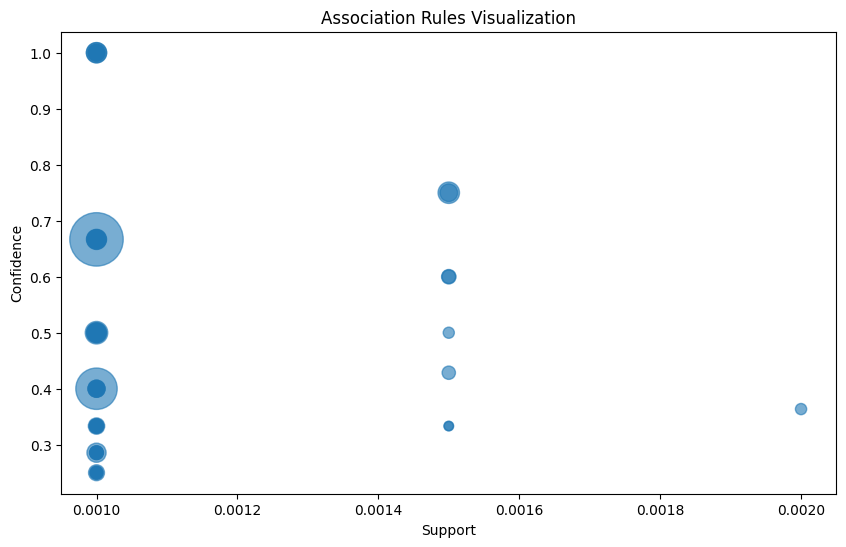

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    resultsinDataFrame['Support'],
    resultsinDataFrame['Confidence'],
    s=resultsinDataFrame['Lift'] * 10,  
    alpha=0.6
)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules Visualization')

plt.show()